# Aproximación de una función definida

Comenzaremos con algo simple que nos permita adquirir una buena base. En esta ocasión la red neuronal aprenderá la siguiente relación entre dos números. La relación viene determinada por la siguiente expresión:

```
def función_hw(x):
     y = (2 * x) - 1
     return y
```

Entonces, ¿cómo puede aprender una relación que a priori es deconocida? ¡Usando datos! Al alimentarlo con un conjunto de x e y, debería poder descubrir la relación entre ellos.
Obviamente, este es un paradigma muy diferente de lo que podríamos estar acostumbrado.

## Importamos los modulos que vamos a necesitar

Importamos [TensorFlow](https://www.tensorflow.org/) y lo llamamos `tf` por convención y facilidad de uso.

Luego, importamos una biblioteca llamada [`numpy`](https://numpy.org) que ayuda a representar los datos como matrices fácilmente y a optimizar las operaciones numéricas.

El marco que usará para construir una red neuronal como una secuencia de capas se llama [`keras`](https://keras.io/).

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow import keras

In [ ]:
tf.__version__

'2.19.0'

In [ ]:
dir(tf)

['AggregationMethod',
 'Assert',
 'CriticalSection',
 'DType',
 'DeviceSpec',
 'GradientTape',
 'Graph',
 'IndexedSlices',
 'IndexedSlicesSpec',
 'Module',
 'Operation',
 'OptionalSpec',
 'RaggedTensor',
 'RaggedTensorSpec',
 'RegisterGradient',
 'SparseTensor',
 'SparseTensorSpec',
 'Tensor',
 'TensorArray',
 'TensorArraySpec',
 'TensorShape',
 'TensorSpec',
 'TypeSpec',
 'UnconnectedGradients',
 'Variable',
 'VariableAggregation',
 'VariableSynchronization',
 '_API_MODULE',
 '_KerasLazyLoader',
 '__all__',
 '__builtins__',
 '__cached__',
 '__compiler_version__',
 '__cxx11_abi_flag__',
 '__cxx_version__',
 '__doc__',
 '__file__',
 '__git_version__',
 '__internal__',
 '__loader__',
 '__monolithic_build__',
 '__name__',
 '__operators__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_api',
 '_compat',
 '_current_file_location',
 '_current_module',
 '_fi',
 '_initializers',
 '_inspect',
 '_kernel_dir',
 '_ll',
 '_losses',
 '_major_api_version',
 '_metrics',
 '_module_dir',


## Definimos y compilamos la red neuronal

Crearemos la red neuronal más simple posible, formada por una capa de una única neurona. Utilizaremos la clase [Sequential](https://keras.io/api/models/secuencial/) de Keras, la cual permite definir la red como una secuencia de [capas](https://keras.io /api/capas/). Podemos usar una sola capa [Dense](https://keras.io/api/layers/core_layers/dense/) para construir esta red simple como se muestra a continuación. En la primera capa siempre debemos indicar el tamaño del vector de entrada, en esta caso de una única dimensión.

In [ ]:
# Construimos un modelo simple secuencial
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


A continuación compilaremos la red neuronal, para ello, debemos especificar dos funciones: una [loss function](https://keras.io/api/losses/) y un [optimizer](https://keras.io/api/optimizers/).

Recordemos que la relación definida inicialmente era `y=2x-1`. Cuando estamos durante la fase de entrenamiento, nuestro modelo comienza a hacer suposiciones, tal vez `y=10x+10`. La loss function mide las respuestas adivinadas contra las respuestas correctas conocidas y mide como de bien o de mal nos estamos acercando a nuestro valor correcto.

Posteriormente, utilizamos la función optimizer para modificar las variables de la red neuronal de tal forma que el valor devuelto por la función de pérdidas sea mínimo.

Además, debemos identificar el número de veces, épocas, que los datos deben pasar por nuestra red neuronal. Cuanta mayor sea la complejidad del problema, más veceses deberá recorrer la red neuronal nuestros datos durante el entrenamiento.

En este caso utilizaremos error cuadrático medio como loss function y stochastic gradient descent como optimizer.

Poco a poco iremos viendo cuales son las más apropiadas según el tipo de problema.

Dense(units=1): Indica que la capa tiene 1 neurona.
input_shape=[1]: Define que la entrada será un vector de una dimensión (un solo número xx).

Esto equivale a una ecuación lineal simple:
y=wx+b


Donde w es el peso y b es el sesgo. Inicialmente, estos parámetros se inicializan aleatoriamente.

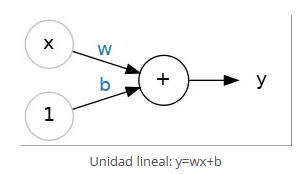
  
)

In [ ]:
# Compilamos el modelo
model.compile(loss='mean_squared_error', optimizer='sgd')


## Proporcionar los datos de entrenamiento

A continuación crearemos nuestro conjunto de datos de entrenamiento, los realizaremos acorde a la relación definida antes. Utilizaremos Numpy para definir los arrays.


In [ ]:
# Declaramos los vectores de entrenamiento: y=2x-1
x = np.array([-1.0,0.0,1.0,2.0,3.0,4.0], dtype=float)
y = np.array([-3.0,-1.0, 1.0, 3.0, 5.0, 7.0], dtype=float)

# Entrenando la red neuronal

El proceso de entrenamiento de la red neuronal, donde 'aprende' la relación entre las x y las y, se encuentra en [`model.fit()`](https://keras.io/api/models/model_training_apis/#fit-método). Aquí es donde tiene lugar la magia. Inicialmente se inicilizan las pesos de la red, se pasan los datos de entrada, se calcula la function loss, con el optimizer se modifican los pesos de la red, y se vuelve a iniciar el proceso.

In [ ]:
# Entrenamos el modelo
model.fit(x,y, epochs=15)


Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - loss: 47.1861
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 37.5070
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 29.8841
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 23.8791
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 19.1471
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 15.4167
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.4746
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 10.1529
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 8.3192
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 6.8698
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 5.7228
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 4.8139
Epoch 13/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 4.0924
Epoch 14/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 3.5185
Epoch 15/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 3.0608


Ahora tenemos un modelo que ha sido entrenado para aprender la relación entre `x` e `y`. Podemos usar el método [`model.predict()`](https://keras.io/api/models/model_training_apis/#predict-method) para que descubra la `y` cuando tenemos una `x` desconocida. Entonces, por ejemplo, si `x=10`, ¿Qué valor de `y` obtendremos?

In [ ]:
# Hacemos una predicción
model.predict(np.array([10.0]))

#10*2-1 = 19


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


array([[10.843494]], dtype=float32)

Podrías haber pensado en '19', ¿verdad? Pero terminó siendo un poco por debajo. ¿Por qué crees que es?

Recuerde que las redes neuronales se ocupan de las probabilidades. Entonces, dados los datos con los que alimentamos el modelo, calculó que existe una probabilidad muy alta de que la relación entre `x` e `y` sea `y=2x-1`, pero con solo 6 puntos de datos no podemos estar seguros.

A medida que trabajemos con redes neuronales, veremos que este patrón se repite. Casi siempre trataremos con probabilidades.

**Resumen de la práctica**:

    - Las redes neuronales no "saben" las reglas de antemano. Necesitan ejemplos para aprender.
    - Con suficiente entrenamiento y datos, el modelo puede aproximar relaciones matemáticas con alta precisión.
    - Los resultados siempre están sujetos a la naturaleza probabilística de las redes neuronales